In [19]:
import numpy as np
from ase.io import read, write
from scipy import optimize
import xyzrender


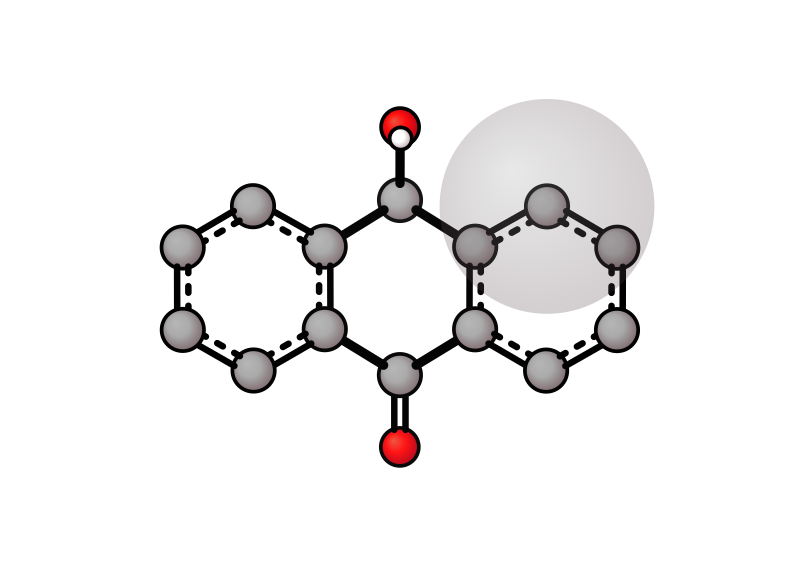

In [42]:
cfg = xyzrender.build_config("default", transparent=True)
mol = xyzrender.load('molecule1.xyz')
xyzrender.render(mol, config=cfg, output='molecule1.png', vdw=[11])


In [ ]:
mol1 = read('molecule1.xyz')
mol2 = read('molecule2.xyz')

# Define function for translating molecule 2 on the surface of the sphere around molecule 1
def translate_on_sphere(coords, atom_position, sphere_center, theta, phi, sphere_radius):
    # Convert spherical coordinates to Cartesian coordinates
    x = sphere_center[0] + sphere_radius * np.sin(theta) * np.cos(phi)
    y = sphere_center[1] + sphere_radius * np.sin(theta) * np.sin(phi)
    z = sphere_center[2] + sphere_radius * np.cos(theta)
    
    # Calculate the translation vector
    translation_vector = np.array([x, y, z]) - atom_position
    
    # Translate the coordinates of molecule 2
    coords += translation_vector

    return coords

def objective_function_translate(params, index_atom1=0,index_atom2=0):
    theta, phi = params
    coords = mol2.positions.copy()

    opt_coords = translate_on_sphere(coords, mol2[index_atom2].position, mol1[index_atom1].position, theta, phi, 5.0)  # Assuming a sphere radius of 5.0
    
    # Calculate the minimum distance between atoms in molecule 2 and molecule 1
    distances = np.linalg.norm(opt_coords[index_atom2] - mol1.positions, axis=1)
    min_distance = np.min(distances)
    # We want to maximize the minimum distance, so we return the negative of it
    return -min_distance

# Now we optimize the translation of molecule 2 on the surface of the sphere around molecule 1
def optimize_translation(index_atom1=0,index_atom2=0):
    # Bounds for the decision variables (theta and phi)
    bounds_translate = [(0, np.pi), (0, 2 * np.pi)]
    result = optimize.minimize(objective_function_translate, x0=[0, 0], bounds=bounds_translate, args=(index_atom1, index_atom2))
    return result

# Run optimization
pair_of_atoms = [(8, 1), (23, 1), (1, 1), (13, 1), (4, 1), (9, 1), (24, 1), (16, 1), (20, 1), (26, 1), (18, 1), (22, 1)]

for atom1, atom2 in pair_of_atoms:
    atom1 -= 1  # Convert to zero-based index
    atom2 -= 1  # Convert to zero-based index

    result = optimize_translation(atom1, atom2)
    # Generate new xyz file with the optimized translation
    optimized_coords = translate_on_sphere(mol2.positions.copy(), mol2[atom2].position, mol1[atom1].position, result.x[0], result.x[1], 5.0)
    optimized_mol2 = mol2.copy()
    optimized_mol2.set_positions(optimized_coords)
    merged_mol = mol1 + optimized_mol2
    write(f'optimized_structure_{atom1+1}_{atom2+1}.xyz', merged_mol)
    